In [14]:
import os 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import joblib


In [18]:
df = pd.read_csv(r"C:\Users\Vaibhav\Downloads\winequality_red.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [20]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [22]:
df.shape

(1599, 12)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [26]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

- Conclusion 

    - In the dataset we have all numerical column then 

    - Histograms were plotted for all numerical features to examine their distributions, skewness, and range, which helped in deciding the need for feature scaling



In [29]:
# df.hist(figsize=(14,6), bins=20)
# plt.tight_layout()
# plt.show()

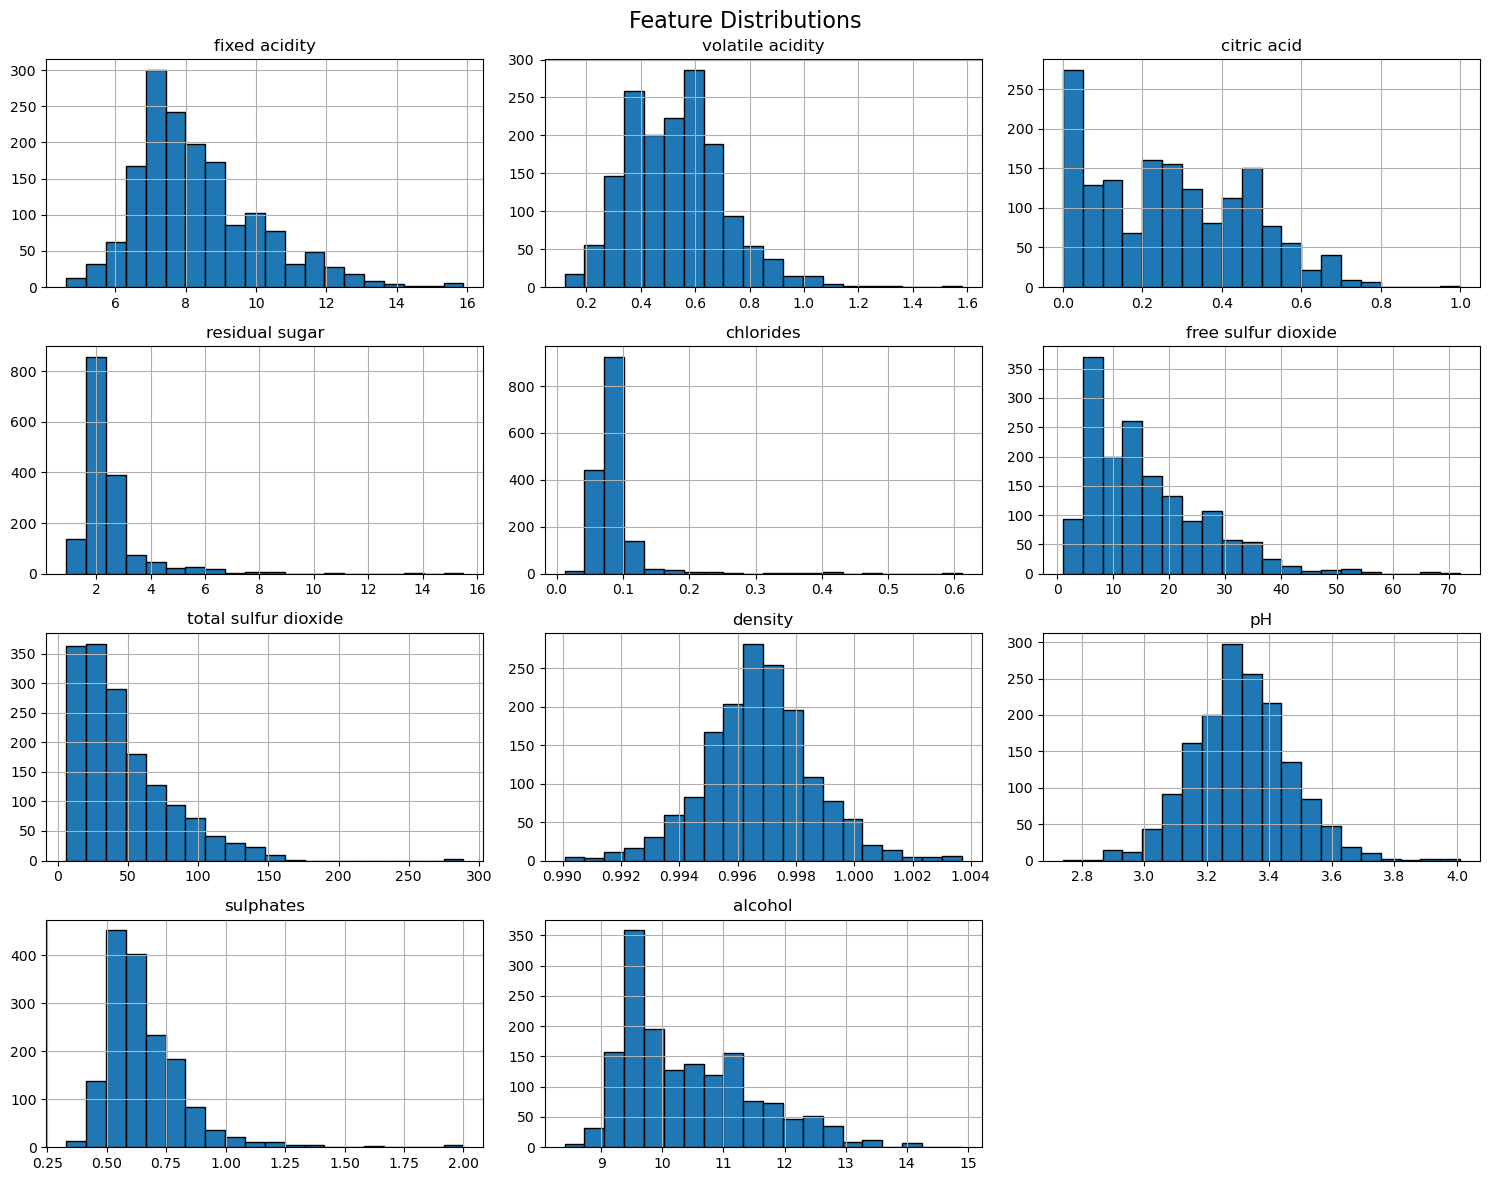

In [31]:
features = df.drop(columns=['quality'])

features.hist(figsize=(15,12), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()


- **Conclusion**

    - Histogram analysis showed that most numerical features exhibit right-skewed distributions with varying ranges 

    - and the presence of outliers, which is typical for real-world chemical datasets. 

    - Since the features are on different scales and some are skewed, feature scaling is necessary. 

    - No categorical encoding was required as all variables are numerical. 

    - Outliers were identified but retained for baseline model training to preserve real data characteristics

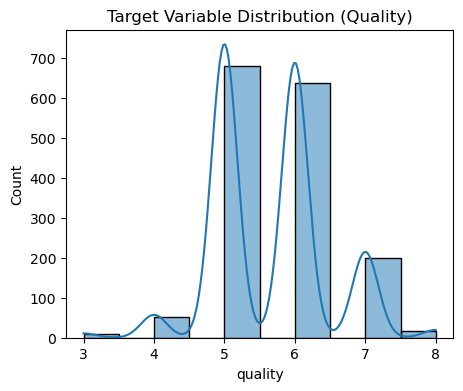

In [34]:

# Target separately
plt.figure(figsize=(5,4))
sns.histplot(df['quality'], bins=10, kde=True)
plt.title("Target Variable Distribution (Quality)")
plt.show()


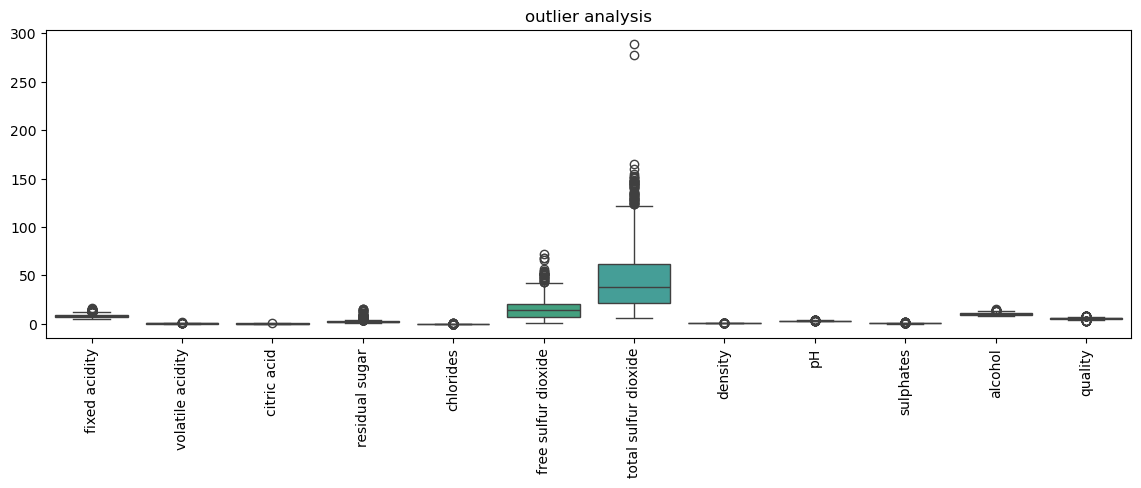

In [36]:
plt.figure(figsize=(14,4))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("outlier analysis")
plt.show()

### Outlier Count

- Then we count the outlier of each column

- And we avoid the output column 

In [39]:
outlier_summary = {}

for col in df.columns:
    if col != 'quality':
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR

        outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_summary[col] = round(outlier_count/len(df) * 100, 2)

outlier_summary

{'fixed acidity': 3.06,
 'volatile acidity': 1.19,
 'citric acid': 0.06,
 'residual sugar': 9.69,
 'chlorides': 7.0,
 'free sulfur dioxide': 1.88,
 'total sulfur dioxide': 3.44,
 'density': 2.81,
 'pH': 2.19,
 'sulphates': 3.69,
 'alcohol': 0.81}

### Conclusion 
 - Outlier analysis using the IQR method revealed that most features contain less than 5% outliers, 
    
 - while residual sugar (9.69%) and chlorides (7%) exhibit higher proportions of extreme values. 
    
 - Since these represent valid chemical measurements, outliers were retained for baseline model training,
    
 - with the intention to apply capping if model performance is negatively impacted.

### Scaliing and fit the data 

- first of all we separate the data(train and test)

- then we will transfrom the data

- it is good for avoiding the data leakage 

In [43]:
# then we separeate the input and output columns 
x = df.drop(columns=['quality'])  #'density', 'citric acid', 'free sulfur dioxide'
y = df['quality']
x

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [45]:
# then we the corrlation of all input columns 
x.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595


<Axes: >

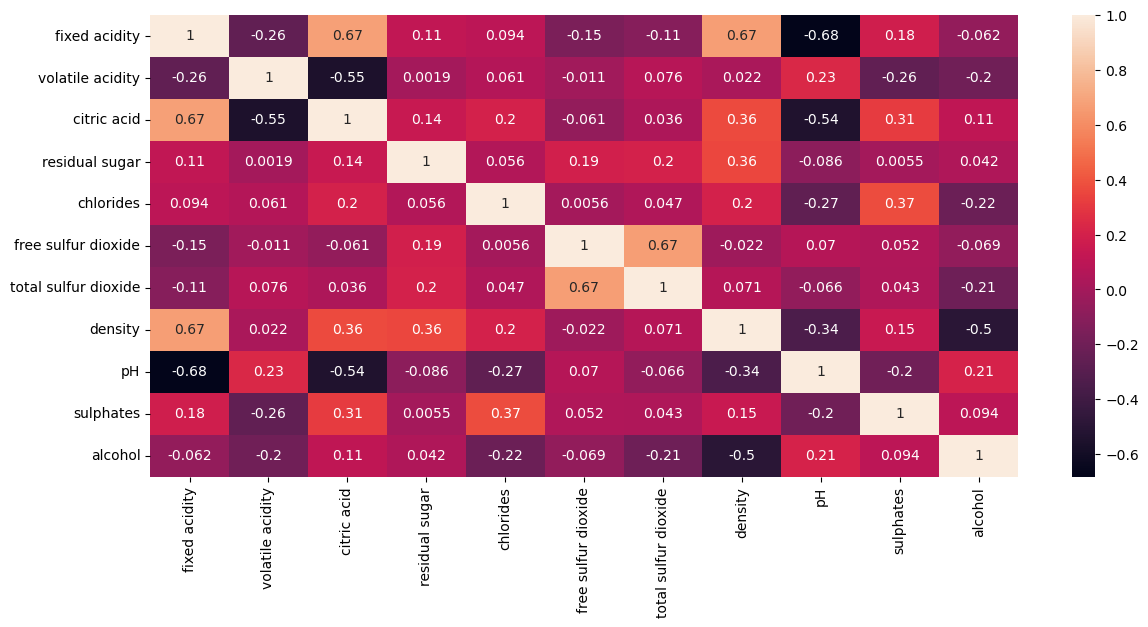

In [47]:
plt.figure(figsize=(14,6))
sns.heatmap(x.corr(), annot=True)

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_df = pd.DataFrame()
vif_df["Feature"] = x.columns
vif_df["VIF"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]

vif_df.sort_values(by="VIF", ascending=False)


,Feature,VIF
7,density,1479.287209
8,pH,1070.967685
10,alcohol,124.394866
0,fixed acidity,74.452265
9,sulphates,21.590621
1,volatile acidity,17.060026
2,citric acid,9.183495
4,chlorides,6.554877
6,total sulfur dioxide,6.519699
5,free sulfur dioxide,6.442682


- Conclusion 

    - then we drop only the density column because it have the highest vif with other column 

In [52]:
# x = df.drop(columns=['quality', ])  #'density', 'citric acid', 'free sulfur dioxide'
# y = df['quality']
x = x.drop(columns=['density'])
vif_df = pd.DataFrame()
vif_df["Feature"] = x.columns
vif_df["VIF"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]

vif_df.sort_values(by="VIF", ascending=False)


,Feature,VIF
7,pH,158.025734
9,alcohol,121.980842
0,fixed acidity,40.216574
8,sulphates,21.552410
1,volatile acidity,17.058940
2,citric acid,9.149028
5,free sulfur dioxide,6.390157
6,total sulfur dioxide,6.096300
4,chlorides,6.017799
3,residual sugar,4.662789


- Conclsuion 

 - After removing the density feature to reduce multicollinearity,

 - the model performance remained unchanged with an R² of approximately 0.40.

 - This indicates that density was a redundant feature and

 - that the simplified model retained equivalent predictive capability

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# then we save our transfroming model 
scaler = StandardScaler()

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

# then we check the shape 
x_test.shape, x_train.shape,y_test.shape, y_train.shape


# then we apply the standard scaler for getting the tranform dara 

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.fit_transform(x_test)


- Conclusion 

    - For Linear Regression, feature scaling is applied only to the input variables
    
    -  to ensure fair coefficient estimation.
 
    -  The target variable does not require scaling.
 
    -   since it is not involved in distance calculations and predictions are expected in the original scale.


In [59]:
X_train_scaled[:2]

array([[ 0.21833164,  0.88971201,  0.19209222,  0.30972563, -0.04964208,
         0.69100692,  1.04293362,  1.09349989,  0.45822284,  1.12317723],
       [-1.29016623, -1.78878251,  0.65275338, -0.80507963, -0.45521361,
         2.38847304,  3.59387025, -0.40043872, -0.40119696,  1.40827174]])

In [61]:
X_test_scaled[:2]

array([[-0.33399129,  0.24258119, -0.96313679,  0.02140418,  0.83730066,
        -0.16962178,  0.00884052, -0.44256111,  0.0634928 , -0.75508835],
       [-0.27864317, -0.09492307, -0.49458376, -0.6712254 , -0.04244065,
         0.46521996,  1.72151211,  0.51996419, -1.15964614, -0.84471308]])

- Then we train our model 

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error, mean_absolute_error



#  then we store our model in a variable 
Lr = LinearRegression()


#  then we fit our data into the model 

Lr.fit(X_train_scaled, y_train)

LinearRegression()

In [66]:
# then we check the coef 
Lr.coef_

array([ 0.02331679, -0.18076208, -0.0277002 ,  0.00314215, -0.08978037,
        0.05913454, -0.12106107, -0.06864536,  0.14444443,  0.3065718 ])

In [68]:
# Intercept 
Lr.intercept_

5.623924941360438

In [70]:
# then we make the prediction 

Y_pred = Lr.predict(X_test_scaled)
Y_pred[:3]

array([5.32082243, 5.00692739, 5.68468075])

In [72]:
error = y_test -Y_pred
error[:5]

803     0.679178
124    -0.006927
350     0.315319
682    -0.437540
1326    0.308406
Name: quality, dtype: float64

In [74]:
# then we calculate the performace metrixs of linear regression model 
# y_test --> y_actual 

R2_Score = r2_score(y_test, Y_pred)

MSE = mean_squared_error(y_test, Y_pred)

RMSE = root_mean_squared_error(y_test,Y_pred)

print(f"Thr R2_Score or Accuracy of the model {round(R2_Score,3)}")
print(f"The Mean Sqaure Eror of the model is {round(MSE,3)}")
print(f"The Root Mean Sqaure Eror of the model is {round(RMSE,3)}")

Thr R2_Score or Accuracy of the model 0.401
The Mean Sqaure Eror of the model is 0.391
The Root Mean Sqaure Eror of the model is 0.626


In [76]:
# 1. Enter your values here
r_squared = 0.402     # Your R2
n = 1599              # Number of rows
k = 8                # Number of independent variables

# 2. The Calculation
adj_r2 = 1 - ((1 - r_squared) * (n - 1) / (n - k - 1))

# 3. Output
print(f"The Adjusted R2 is: {adj_r2:.4f}")

The Adjusted R2 is: 0.3990


## Then we check the Assumptions in Linear regression 

**Linearity**

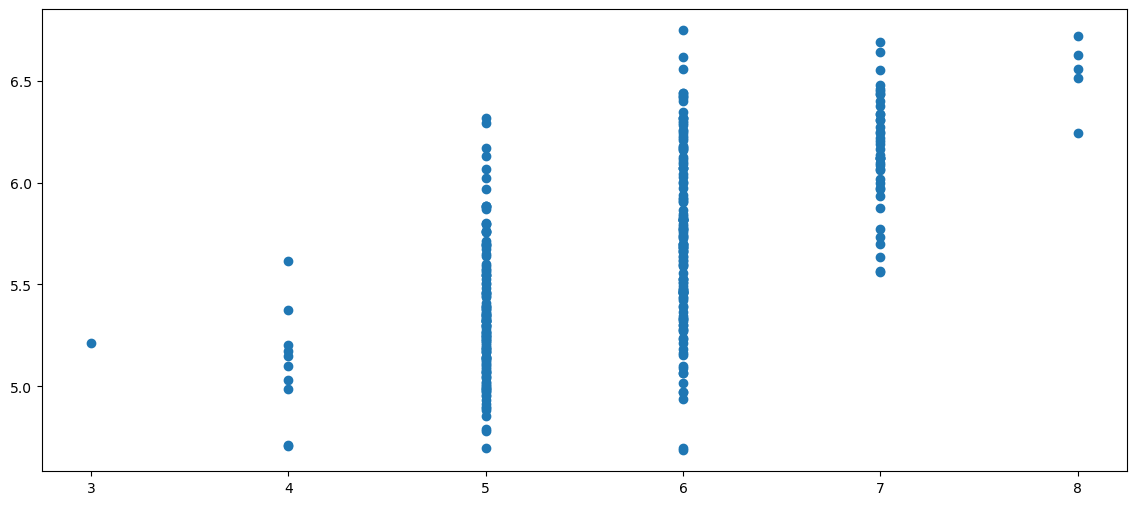

In [80]:
plt.figure(figsize=(14,6))
plt.scatter(x=y_test, y=Y_pred)

- **Conclusion**

    - The Actual vs Predicted plot shows a clear linear relationship between observed and predicted wine quality values.
    
    - Although some dispersion exists due to the discrete and subjective nature of the target variable,
 
    - no strong non-linear patterns were observed.
 
    - Therefore, the linearity assumption of Linear Regression is reasonably satisfied.

**Homoscedasticity**

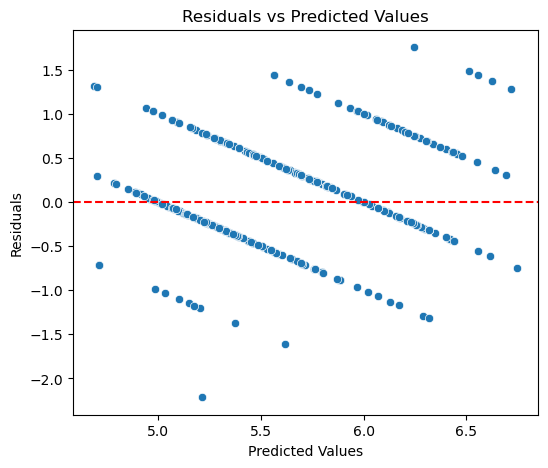

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# residuals = y_test - y_test_pred

plt.figure(figsize=(6,5))
sns.scatterplot(x=Y_pred, y=error)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()


- **Conclusion**

    - Homoscedasticity assumption is reasonably satisfied

    - There is:

        - No strong heteroscedasticity

        - No clear variance pattern

        - Random spread around zero

**Histogram**

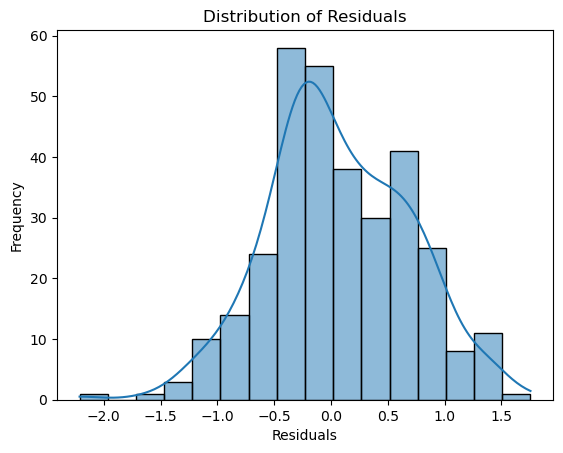

In [88]:

sns.histplot(error, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


- **Conclusion**

    - The normality assumption is reasonably satisfied

    - The histogram and KDE of residuals indicate an approximately normal distribution centered around zero. 

    - Minor deviations at the tails are observed, 
    
    - which are expected in real-world data. Overall, 
    
    - the normality assumption of Linear Regression is reasonably satisfied

**Independence of Errors**

In [92]:
from statsmodels.stats.stattools import durbin_watson

dw_stat = durbin_watson(error)
dw_stat

1.8720987036407617

- **Conclusion**

    - Independence of errors assumption is satisfied

        - The Durbin–Watson statistic was found to be 1.87, which is close to 2,
        
        - indicating no significant autocorrelation among residuals.
     
        - Therefore, the independence of errors assumption is satisfied

**Overall Assumptions Conclusion**

- All key assumptions of Linear Regression were evaluated and found to be reasonably satisfied.

- The linearity between predictors and the target variable was observed,

- residuals showed approximately constant variance, followed an approximately normal distribution,

- and were independent as confirmed by the Durbin–Watson test.

- Multicollinearity was assessed and managed through feature selection.

- Therefore, the Linear Regression model is statistically valid and suitable for prediction.

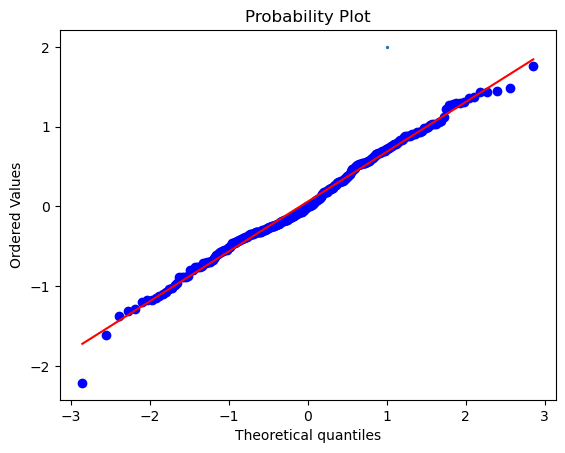

In [96]:
import scipy.stats as stats
plt.scatter(1,2,2)
stats.probplot(error, dist="norm", plot=plt)
plt.show()

- **Then we save our model**

In [ ]:
joblib.dump(Lr, "wine_quality_model.joblib")
print("✅ Model is Perfectly Save")

- Then for converting the row data into the scalable range then we want to scaler thenwe will also save our standrdscaler model 

In [ ]:
joblib.dump(scaler, "wine_quality_scaler.joblib")
print("✅ Scaler Model is Perfectly Save")

In [ ]:
# we also want the feature names for predicting then we also put the feature names 
feature_names = x.columns.tolist()
joblib.dump(feature_names, "feature_names.joblib")
print("✅ Feature Name is Perfectly Save")

In [ ]:
feature_names
